### Explanatory Data Analysis (EDA)

Imports

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
import os

Raw Data

In [14]:
movies = pd.read_csv('../data/raw/movies.csv')
ratings = pd.read_csv('../data/raw/ratings.csv')
tags = pd.read_csv('../data/raw/tags.csv')
links = pd.read_csv('../data/raw/links.csv')

### Data ingestion and preprocessing

In [15]:
display(movies.head(5))

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [16]:
movies['release_year'] = movies['title'].str.extract(r'\((\d{4})\)')
movies['release_year'] = pd.to_numeric(movies['release_year'], errors='coerce')
movies['title_clean'] = movies['title'].str.replace(r'\s*\(\d{4}\)', '', regex=True).str.strip()

In [17]:
ratings['datetime'] = pd.to_datetime(ratings['timestamp'], unit='s')
tags['datetime'] = pd.to_datetime(tags['timestamp'], unit='s')

In [18]:
ratings['rating_year'] = ratings['datetime'].dt.year
ratings['rating_month'] = ratings['datetime'].dt.month

In [19]:
df = ratings.merge(movies, on='movieId', how='left')

In [20]:
missing_data = df.isnull().sum()
print("\nMissing Values per Column:")
print(missing_data[missing_data > 0])


Missing Values per Column:
release_year    18
dtype: int64


In [21]:
duplicates = df.duplicated(subset=['userId', 'movieId']).sum()
print(f"\nDuplicates Found: {duplicates}")


Duplicates Found: 0


In [22]:
print("\nProcessed Master DataFrame Preview:")
display(df[['userId', 'title_clean', 'release_year', 'rating', 'datetime']].head())


Processed Master DataFrame Preview:


,userId,title_clean,release_year,rating,datetime
0,1,Toy Story,1995.0,4.0,2000-07-30 18:45:03
1,1,Grumpier Old Men,1995.0,4.0,2000-07-30 18:20:47
2,1,Heat,1995.0,4.0,2000-07-30 18:37:04
3,1,Seven (a.k.a. Se7en),1995.0,5.0,2000-07-30 19:03:35
4,1,"Usual Suspects, The",1995.0,5.0,2000-07-30 18:48:51


In [23]:
processed_dir = '../data/processed'
df.to_parquet(f'{processed_dir}/master_data.parquet', index=False)
movies.to_parquet(f'{processed_dir}/movies_clean.parquet', index=False)
ratings.to_parquet(f'{processed_dir}/ratings_clean.parquet', index=False)

### **Univariate Analysis**

#### Rating distribution

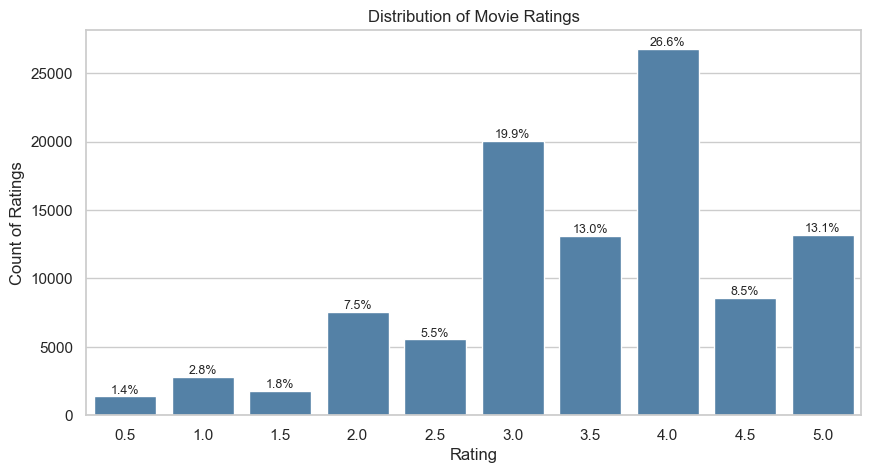

In [28]:
plt.figure(figsize=(10, 5))
ax = sns.countplot(data=df, x='rating', color='steelblue')
plt.title('Distribution of Movie Ratings')
plt.xlabel('Rating')
plt.ylabel('Count of Ratings')
total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=9)
plt.show()

Based on the distribution of the movie ratings, we can observe several patterns
1. Postivity bias: The ratings are not normally distributed. The platform leans heavily positive, with the vast majority of ratings ($\approx 81\%$) falling at $3.0$ stars or higher. The single most common rating is $4.0$ ($26.6\%$). This suggests that users predominantly rate movies they already suspect they will enjoy, or they simply avoid finishing and rating bad movies.
2. Full-star preference: There is a clear psychological bias toward whole numbers. Users are significantly more likely to give a $3.0$, $4.0$, or $5.0$ than they are to use the half-star ratings ($2.5$, $3.5$, $4.5$).

Conclusion for futher work:
Because of the leftward skewness, an absolute rating of $3.0$ is actually considered a below-average score. If we feed raw ratings directly into a Matrix Factorization model (like SVD), it will struggle to differentiate true preferences. Therefore, before training, we must implement baseline predictors. We need to center the ratings by subtracting the global average rating, and potentially the user's specific mean rating, so the model learns deviations from the baseline rather than absolute scores.

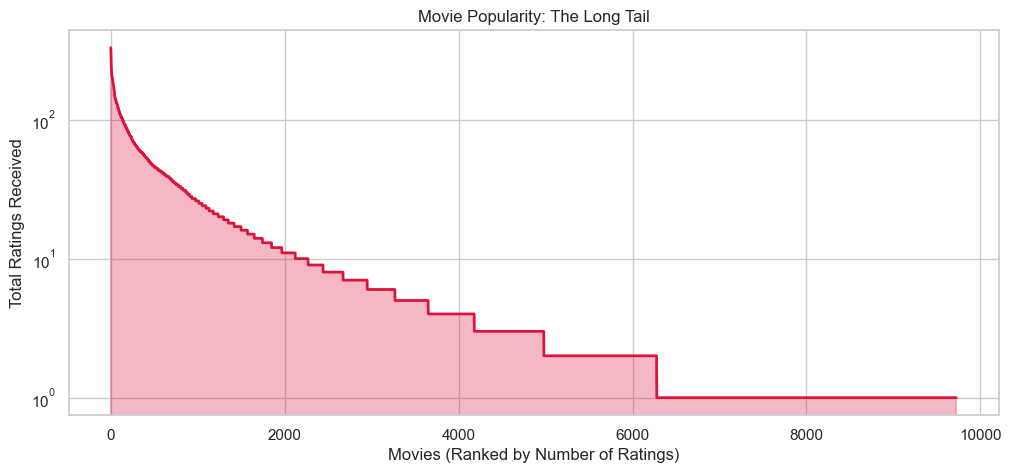

In [29]:
movie_rating_counts = df['movieId'].value_counts()
plt.figure(figsize=(12, 5))
plt.plot(movie_rating_counts.values, color='crimson', linewidth=2)
plt.fill_between(range(len(movie_rating_counts)), movie_rating_counts.values, color='crimson', alpha=0.3)
plt.title('Movie Popularity: The Long Tail')
plt.xlabel('Movies (Ranked by Number of Ratings)')
plt.ylabel('Total Ratings Received')
# Log scale helps visualize the extreme drop-off
plt.yscale('log') 
plt.show()

In [31]:
print(f"Median ratings per movie: {movie_rating_counts.median()}")
print(f"Movies with < 5 ratings: {(movie_rating_counts < 5).sum()} (Cold Start Items)")

Median ratings per movie: 3.0
Movies with < 5 ratings: 6074 (Cold Start Items)


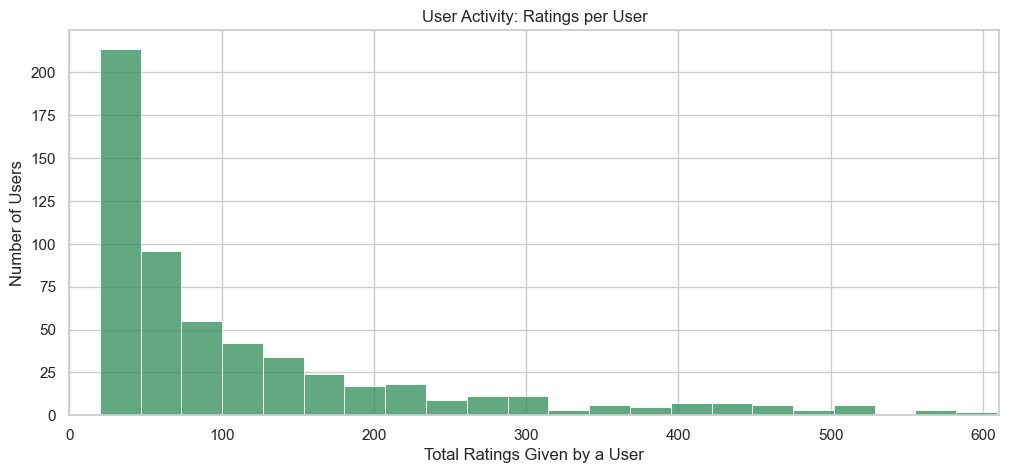

In [32]:
user_rating_counts = df['userId'].value_counts()
plt.figure(figsize=(12, 5))
sns.histplot(user_rating_counts, bins=100, color='seagreen', kde=False)
plt.title('User Activity: Ratings per User')
plt.xlabel('Total Ratings Given by a User')
plt.ylabel('Number of Users')
# Limit x-axis to zoom in on the majority of users, ignoring the extreme outliers for the plot
plt.xlim(0, user_rating_counts.quantile(0.95)) 
plt.show()

In [33]:
print(f"Median ratings per user: {user_rating_counts.median()}")
print(f"Users with < 20 ratings: {(user_rating_counts < 20).sum()} (Cold Start Users)")

Median ratings per user: 70.5
Users with < 20 ratings: 0 (Cold Start Users)


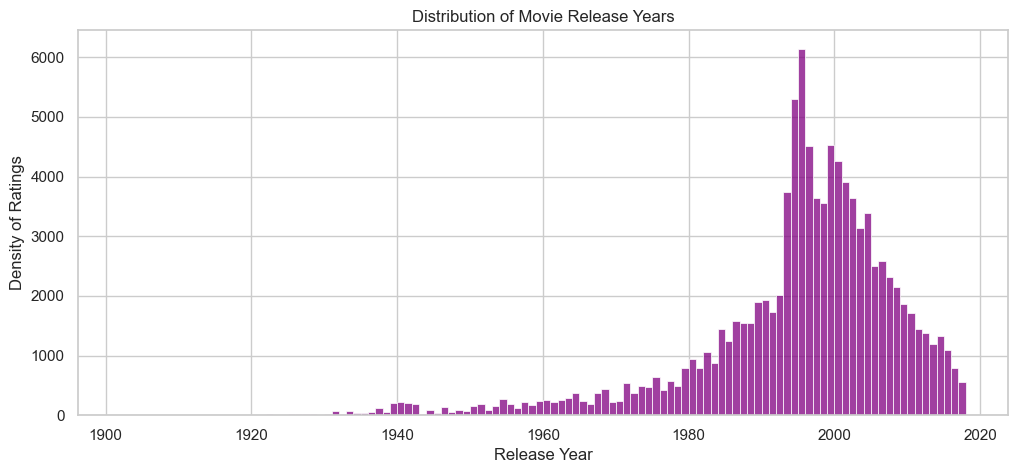

In [34]:
plt.figure(figsize=(12, 5))
sns.histplot(data=df, x='release_year', bins=int(df['release_year'].max() - df['release_year'].min()), color='purple')
plt.title('Distribution of Movie Release Years')
plt.xlabel('Release Year')
plt.ylabel('Density of Ratings')
plt.show()